# Sesión 8

+ Esta sesión trabajaremos con datos del Federal Reserve Bank of St. Louis, para los amigos mejor conocido como FRED.

+ El sitio web es https://fred.stlouisfed.org/

+ Vamos a crear una cuenta de usuario... simplemente necesitamos un correo.

+ Vamos a TOOLS -> FRED API -> Api keys -> Picar al botón de "Request Api Key"

+ Vamos a copiar y pegar en un txt esa cadena de caracteres

+ Vamos a necesitar instalar la librería que conecta python con la API de FRED

In [1]:
!pip install fredapi

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px # Otra librería para graficar

from fredapi import Fred # Contiene las aplicaciones para hacer las solicitudes a la API de FRED
import time # Vamos a poner un timer en una función

In [3]:
mi_fred_key = 'a8a4e9d276de3feffda56db4e8ee6d53'

+ Lo primero que vamos a hacer es genera un conector con la API de FRED. Esto se hace con la función `Fred`

In [4]:
objeto_fred = Fred(api_key = mi_fred_key)

In [5]:
objeto_fred

In [6]:
# ¿Qué tipo de objeto es este?
type(objeto_fred)

fredapi.fred.Fred

+ Empezaremos haciendo una búsqueda de algunas series.

+ Una clásica es el histórico del Standard and Poors 500, que es un instrumento financiero del mercado estadounidense

+ Voy a ocupar la función `search('mi_busqueda')`

In [7]:
busqueda = objeto_fred.search('S&P')

+ Es como si estuviera haciendo la búsqueda en el buscador de la página web de FRED.

In [8]:
busqueda

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
SP500,SP500,2026-03-19,2026-03-19,S&P 500,2016-03-21,2026-03-19,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-03-19 19:02:27-05:00,90,The observations for the S&P 500 represent the...
CSUSHPINSA,CSUSHPINSA,2026-03-19,2026-03-19,S&P Cotality Case-Shiller U.S. National Home P...,1987-01-01,2025-12-01,Monthly,M,Index Jan 2000=100,Index Jan 2000=100,Not Seasonally Adjusted,NSA,2026-02-24 08:15:26-06:00,83,"For more information regarding the index, plea..."
CSUSHPISA,CSUSHPISA,2026-03-19,2026-03-19,S&P Cotality Case-Shiller U.S. National Home P...,1987-01-01,2025-12-01,Monthly,M,Index Jan 2000=100,Index Jan 2000=100,Seasonally Adjusted,SA,2026-02-24 08:15:04-06:00,73,"For more information regarding the index, plea..."
SPCS20RSA,SPCS20RSA,2026-03-19,2026-03-19,S&P Cotality Case-Shiller 20-City Composite Ho...,2000-01-01,2025-12-01,Monthly,M,Index Jan 2000=100,Index Jan 2000=100,Seasonally Adjusted,SA,2026-02-24 08:14:08-06:00,59,"For more information regarding the index, plea..."
SFXRSA,SFXRSA,2026-03-19,2026-03-19,S&P Cotality Case-Shiller CA-San Francisco Hom...,1987-01-01,2025-12-01,Monthly,M,Index Jan 2000=100,Index Jan 2000=100,Seasonally Adjusted,SA,2026-02-24 08:13:40-06:00,58,"For more information regarding the index, plea..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HC01ESTVC1641025,HC01ESTVC1641025,2026-03-19,2026-03-19,High School Graduate or Higher (5-year estimat...,2010-01-01,2024-01-01,Annual,A,Percent,%,Not Seasonally Adjusted,NSA,2026-01-29 09:39:21-06:00,1,Estimate of educational attainment for populat...
HC01ESTVC1617069,HC01ESTVC1617069,2026-03-19,2026-03-19,High School Graduate or Higher (5-year estimat...,2010-01-01,2024-01-01,Annual,A,Percent,%,Not Seasonally Adjusted,NSA,2026-01-29 09:43:59-06:00,1,Estimate of educational attainment for populat...
HC01ESTVC1619197,HC01ESTVC1619197,2026-03-19,2026-03-19,High School Graduate or Higher (5-year estimat...,2010-01-01,2024-01-01,Annual,A,Percent,%,Not Seasonally Adjusted,NSA,2026-01-29 09:43:16-06:00,1,Estimate of educational attainment for populat...


+ Esto parece ser un pandas DataFrame con los primero 1000 resultados de la búsqueda

In [9]:
type(busqueda)

pandas.core.frame.DataFrame

+ Efectivamente es un pandas DataFrame

In [10]:
busqueda.shape

(1000, 15)

+ Son 1000 renglones (uno por cada resultado de la búsqueda) y 15 columnas info de la serie que propone cada búsqueda

In [11]:
busqueda = objeto_fred.search('S&P', order_by='popularity')

In [12]:
busqueda

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
BAMLH0A0HYM2,BAMLH0A0HYM2,2026-03-19,2026-03-19,ICE BofA US High Yield Index Option-Adjusted S...,1996-12-31,2026-03-18,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-19 09:03:30-05:00,100,The ICE BofA Option-Adjusted Spreads (OASs) ar...
SP500,SP500,2026-03-19,2026-03-19,S&P 500,2016-03-21,2026-03-19,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-03-19 19:02:27-05:00,90,The observations for the S&P 500 represent the...
BAMLC0A0CM,BAMLC0A0CM,2026-03-19,2026-03-19,ICE BofA US Corporate Index Option-Adjusted Sp...,1996-12-31,2026-03-18,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-19 09:04:23-05:00,86,The ICE BofA Option-Adjusted Spreads (OASs) ar...
BAMLH0A0HYM2EY,BAMLH0A0HYM2EY,2026-03-19,2026-03-19,ICE BofA US High Yield Index Effective Yield,1996-12-31,2026-03-18,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-19 09:04:21-05:00,85,This data represents the effective yield of th...
CSUSHPINSA,CSUSHPINSA,2026-03-19,2026-03-19,S&P Cotality Case-Shiller U.S. National Home P...,1987-01-01,2025-12-01,Monthly,M,Index Jan 2000=100,Index Jan 2000=100,Not Seasonally Adjusted,NSA,2026-02-24 08:15:26-06:00,83,"For more information regarding the index, plea..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HC01ESTVC1701001,HC01ESTVC1701001,2026-03-19,2026-03-19,Bachelor's Degree or Higher (5-year estimate) ...,2010-01-01,2024-01-01,Annual,A,Percent,%,Not Seasonally Adjusted,NSA,2026-01-29 09:37:43-06:00,3,Estimate of educational attainment for populat...
Q16090USQ509SNBR,Q16090USQ509SNBR,2026-03-19,2026-03-19,"Diffusion Index, Profits Per Dollar of Sales, ...",1947-04-01,1958-10-01,Quarterly,Q,Percent Expanding,% Expanding,Seasonally Adjusted,SA,2012-08-20 09:32:53-05:00,3,Data Include All Two-Digit Manufacturing Indus...
XRNCUSMKA618NRUG,XRNCUSMKA618NRUG,2026-03-19,2026-03-19,Exchange Rate (market+estimated) for the forme...,1990-01-01,2023-01-01,Annual,A,National Currency Units per US Dollar,National Currency Units per US $,Not Seasonally Adjusted,NSA,2026-02-04 11:43:59-06:00,3,Source ID: xr When using these data in your r...


+ También me devulve un pandas DataFrame con los 1000 primeros resultado de la búsqueda, ordenados por popularidad.

+ Hasta el momento sólo hemos hecho búsquedas, no descargado datos aún

+ Podemos decir que hasta el momento a lo más hemos descargado metadatos (datos de los datos)

+ Si vemos el pandas DataFrame vemos que hay una serie que tiene el id 'SP500' y esa es la que quiero descargar

+ Para hacer la descarga efectivamente, usamos la función `get_series` aplicada al `objeto_fred`

In [13]:
# Descargo una serie específica
serie_sp500 = objeto_fred.get_series(series_id = 'SP500')

In [14]:
serie_sp500

,0
2016-03-21,2051.60
2016-03-22,2049.80
2016-03-23,2036.71
2016-03-24,2035.94
2016-03-25,NaN
...,...
2026-03-13,6632.19
2026-03-16,6699.38
2026-03-17,6716.09
2026-03-18,6624.70


+ ¿De qué tiene cara este objeto que nos devolvió?

+ Medio nos huele a que es una serie de pandas

In [15]:
type(serie_sp500)

pandas.core.series.Series

+ Este tipo de series se pueden graficar fácilmente

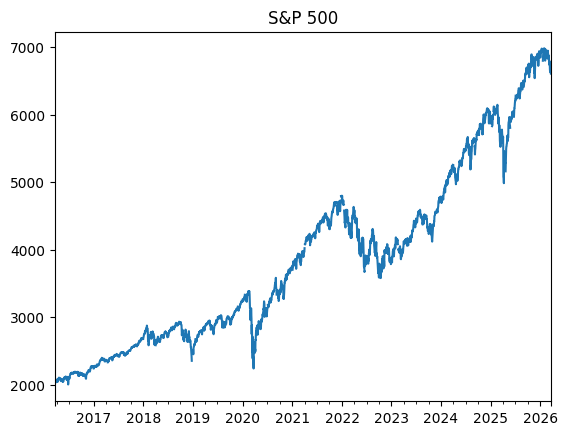

In [16]:
serie_sp500.plot(title='S&P 500')
plt.show()

+ Vamos a hacer otra búsqueda un poquito más interesante

+ Supongamos que nos interesa la tasa de desempleo histórica por estado... obviamente de Estados Unidos de Norteamérica.

+ Empecemos buscando... como lo haríamos en la página web

In [17]:
otra_busqueda = objeto_fred.search('unemployment rate state')

In [18]:
otra_busqueda

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-19,2026-03-19,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,98,The unemployment rate represents the number of...
UNRATENSA,UNRATENSA,2026-03-19,2026-03-19,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:13:10-06:00,57,The unemployment rate represents the number of...
UNEMPLOY,UNEMPLOY,2026-03-19,2026-03-19,Unemployment Level,1948-01-01,2026-02-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-03-06 08:12:53-06:00,71,The series comes from the 'Current Population ...
CCSA,CCSA,2026-03-19,2026-03-19,Continued Claims (Insured Unemployment),1967-01-07,2026-03-07,"Weekly, Ending Saturday",W,Number,Number,Seasonally Adjusted,SA,2026-03-19 07:49:43-05:00,70,"Continued claims, also referred to as insured ..."
U6RATE,U6RATE,2026-03-19,2026-03-19,"Total Unemployed, Plus All Persons Marginally ...",1994-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:13:00-06:00,71,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENUC265840010,ENUC265840010,2026-03-19,2026-03-19,Average Weekly Wages for Employees in Total Co...,1990-01-01,2025-07-01,Quarterly,Q,Dollars per Week,$ per Week,Not Seasonally Adjusted,NSA,2026-03-10 11:30:39-05:00,1,Average weekly wages are the wages paid by une...
ENUC166240010,ENUC166240010,2026-03-19,2026-03-19,Average Weekly Wages for Employees in Total Co...,1990-01-01,2025-07-01,Quarterly,Q,Dollars per Week,$ per Week,Not Seasonally Adjusted,NSA,2026-03-10 11:31:59-05:00,1,Average weekly wages are the wages paid by une...
ENUC255440010,ENUC255440010,2026-03-19,2026-03-19,Average Weekly Wages for Employees in Total Co...,1990-01-01,2025-07-01,Quarterly,Q,Dollars per Week,$ per Week,Not Seasonally Adjusted,NSA,2026-03-10 11:30:43-05:00,1,Average weekly wages are the wages paid by une...


+ Como antes, obtenemos un pandas DataFrame con los primeros 1000 resultados de la búsqueda

In [19]:
# Podemos refinar nuestra búsqueda
otra_busqueda = objeto_fred.search('unemployment rate state', filter = ('frequency','Monthly'))

In [20]:
otra_busqueda

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-19,2026-03-19,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,98,The unemployment rate represents the number of...
UNRATENSA,UNRATENSA,2026-03-19,2026-03-19,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:13:10-06:00,57,The unemployment rate represents the number of...
UNEMPLOY,UNEMPLOY,2026-03-19,2026-03-19,Unemployment Level,1948-01-01,2026-02-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-03-06 08:12:53-06:00,71,The series comes from the 'Current Population ...
U6RATE,U6RATE,2026-03-19,2026-03-19,"Total Unemployed, Plus All Persons Marginally ...",1994-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:13:00-06:00,71,The series comes from the 'Current Population ...
LNU03000000,LNU03000000,2026-03-19,2026-03-19,Unemployment Level,1948-01-01,2026-02-01,Monthly,M,Thousands of Persons,Thous. of Persons,Not Seasonally Adjusted,NSA,2026-03-06 08:14:10-06:00,28,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LAUCN212290000000005,LAUCN212290000000005,2026-03-19,2026-03-19,"Employed Persons in Washington County, KY",1990-01-01,2025-12-01,Monthly,M,Persons,Persons,Not Seasonally Adjusted,NSA,2026-02-06 19:20:54-06:00,1,These data come from the Current Population Su...
LAUCN120170000000005,LAUCN120170000000005,2026-03-19,2026-03-19,"Employed Persons in Citrus County, FL",1990-01-01,2025-12-01,Monthly,M,Persons,Persons,Not Seasonally Adjusted,NSA,2026-02-06 19:24:37-06:00,1,These data come from the Current Population Su...
LAUCN060110000000005,LAUCN060110000000005,2026-03-19,2026-03-19,"Employed Persons in Colusa County, CA",1990-01-01,2025-12-01,Monthly,M,Persons,Persons,Not Seasonally Adjusted,NSA,2026-02-06 19:24:45-06:00,1,These data come from the Current Population Su...


In [21]:
type(otra_busqueda)

pandas.core.frame.DataFrame

+ El objeto `otra_busqueda` es un pandas dataframe

+ Podemos navegar dentro de él como ya sabemos

+ Por ejemplo, con la función `query` de los pandas DataFrames de toda la vida.

In [ ]:
# Buscaré que mi serie tenga un ajuste por estacionalidad y que este en porcentaje
otra_busqueda.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')

In [22]:
# Busquemos series que en su título explícitamente tengan la frase 'Unemployment Rate'
otra_busqueda.loc[otra_busqueda['title'].str.contains('Unemployment Rate')]

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-19,2026-03-19,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,98,The unemployment rate represents the number of...
UNRATENSA,UNRATENSA,2026-03-19,2026-03-19,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:13:10-06:00,57,The unemployment rate represents the number of...
LNS14000006,LNS14000006,2026-03-19,2026-03-19,Unemployment Rate - Black or African American,1972-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:56-06:00,67,The series comes from the 'Current Population ...
CAUR,CAUR,2026-03-19,2026-03-19,Unemployment Rate in California,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:30-06:00,65,None
LNU04000006,LNU04000006,2026-03-19,2026-03-19,Unemployment Rate - Black or African American,1972-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:13:59-06:00,26,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HIUR,HIUR,2026-03-19,2026-03-19,Unemployment Rate in Hawaii,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:13-06:00,23,None
NHUR,NHUR,2026-03-19,2026-03-19,Unemployment Rate in New Hampshire,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:06-06:00,19,None
NHURN,NHURN,2026-03-19,2026-03-19,Unemployment Rate in New Hampshire,1976-01-01,2025-12-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-01-28 09:47:43-06:00,16,None


+ Empiezo a ver la luz, porque nuestro objetivo es obtener las tasas de desempleo por estado

+ Ya nos aparecen títulos del estilo "Unemployment Rate in New Hampshire", "Unemployment Rate in Hawaii", etc.

In [23]:
# Pongamos todo junto
# Búsqueda filtrada web
mi_busqueda = objeto_fred.search('unemployment rate state', filter = ('frequency','Monthly'))
# Búsqueda filtrada con operaciones de pandas
mi_busqueda = mi_busqueda.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')
mi_busqueda = mi_busqueda.loc[mi_busqueda['title'].str.contains('Unemployment Rate')]

+ Ya con los criterios de filtrado que le dí a la búsqueda, el resultado de la búsqueda es

In [26]:
mi_busqueda#.index

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-19,2026-03-19,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,98,The unemployment rate represents the number of...
LNS14000006,LNS14000006,2026-03-19,2026-03-19,Unemployment Rate - Black or African American,1972-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:56-06:00,67,The series comes from the 'Current Population ...
CAUR,CAUR,2026-03-19,2026-03-19,Unemployment Rate in California,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:30-06:00,65,None
LNS14024887,LNS14024887,2026-03-19,2026-03-19,Unemployment Rate - 16-24 Yrs.,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:48-06:00,63,The series comes from the 'Current Population ...
LNS14027662,LNS14027662,2026-03-19,2026-03-19,Unemployment Rate - Bachelor's Degree and High...,1992-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:48-06:00,57,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LNS14032183,LNS14032183,2026-03-19,2026-03-19,Unemployment Rate - Asian,2003-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:52-06:00,19,The series comes from the 'Current Population ...
ARUR,ARUR,2026-03-19,2026-03-19,Unemployment Rate in Arkansas,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:22-06:00,28,None
CTUR,CTUR,2026-03-19,2026-03-19,Unemployment Rate in Connecticut,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:36-06:00,28,None


+ Ya sólo tenemos 63 posibles series

+ Nos huele a que sólo deberíamos tener 51 (una por estado)

+ Más una que es la de Puerto Rico

+ Hasta ahora hemos hecho búsquedas "web" de posibles series, no descargado dichas series.

+ Tenemos metadatos, pero no datos en sí.

+ Vamos a descargar todas estas series

In [27]:
# En esta lista vamos a meter todas las series descargadas
lista_descargas = []

for id in mi_busqueda.index:
    results = objeto_fred.get_series(id) # Es justo aquí donde descargo cada una de las 63 series
    results = results.to_frame(name=id) # La convierto en un frame
    lista_descargas.append(results) # Las voy anexando a la lista
    time.sleep(0.1) # IMPORTANTE: Para modular el ritmo de las consultas porque FRED te puede bloquear

+ En el objeto `lista_descargas` están todas las series que ya descargué.

In [29]:
#lista_descargas

+ Es una lista larguita, pues tiene 63 series adentro

+ Vamos a mejor ponerlas en un pandas DataFrame

In [30]:
df_descargas = pd.concat(lista_descargas, axis=1) # columna x columna

In [31]:
df_descargas.head()

,UNRATE,LNS14000006,CAUR,LNS14024887,LNS14027662,LNS14000024,TXUR,M0892AUSM156SNBR,NYUR,ALUR,...,INUR,WVUR,NMUR,UTUR,TNUR,LNS14032183,ARUR,CTUR,HIUR,NHUR
1929-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.69,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.65,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.79,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


+ En el objecto `df_descargas` (que por cierto es un pandas DF) ya viven las 63 series que potencialmente me interesan.

+ Cada columna representa una serie

+ El índice de este dataframe es la fecha... cosa que tiene sentido porque son series de tiempo

+ Los títulos de las columnas están feitos... parece ser que es una clave de algo.

+ Afortunadamente, alguien me soplo (la documentación de la API) que las series que me interesan están codificadas con 4 caracteres. Voy a eliminar el resto

In [32]:
cols_eliminar = []

for i in df_descargas:
    if len(i) > 4: # Si tienes más de 4 caracteres en el nombre, te voy guardando
        cols_eliminar.append(i)

In [33]:
cols_eliminar

['UNRATE',
 'LNS14000006',
 'LNS14024887',
 'LNS14027662',
 'LNS14000024',
 'M0892AUSM156SNBR',
 'M0892BUSM156SNBR',
 'LNS14000003',
 'LNS14000002',
 'LNS14027660',
 'LNS14000009',
 'LNS14000036',
 'U2RATE',
 'LNS14000012',
 'LNS14000001',
 'LNS14027659',
 'LNS14000031',
 'LNS14000032',
 'LASMT261982000000003',
 'LNS14000060',
 'LASMT534266000000003',
 'LNS14032183']

In [34]:
# Voy a eliminar las columnas que no quiero
df_descargas = df_descargas.drop(columns = cols_eliminar)

In [35]:
df_descargas

,CAUR,TXUR,NYUR,ALUR,FLUR,GAUR,ILUR,MIUR,OHUR,LAUR,...,NDUR,INUR,WVUR,NMUR,UTUR,TNUR,ARUR,CTUR,HIUR,NHUR
1929-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,5.6,4.2,4.5,2.7,4.2,3.5,4.4,5.0,4.5,4.3,...,2.6,3.7,4.4,4.2,3.6,3.6,4.1,4.0,2.2,3.0
2025-12-01,5.5,4.3,4.6,2.7,4.3,3.6,4.6,5.0,4.5,4.2,...,2.6,3.5,4.6,4.3,3.6,3.6,4.2,4.2,2.2,3.1
2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


+ Se me hace que no lograré tener info de todos los estados... sólo de 41

In [36]:
# Sólo por orden, trabajare con una copia de ese dataframe
mis_series_historicas = df_descargas.copy()

In [37]:
mis_series_historicas

,CAUR,TXUR,NYUR,ALUR,FLUR,GAUR,ILUR,MIUR,OHUR,LAUR,...,NDUR,INUR,WVUR,NMUR,UTUR,TNUR,ARUR,CTUR,HIUR,NHUR
1929-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,5.6,4.2,4.5,2.7,4.2,3.5,4.4,5.0,4.5,4.3,...,2.6,3.7,4.4,4.2,3.6,3.6,4.1,4.0,2.2,3.0
2025-12-01,5.5,4.3,4.6,2.7,4.3,3.6,4.6,5.0,4.5,4.2,...,2.6,3.5,4.6,4.3,3.6,3.6,4.2,4.2,2.2,3.1
2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


+ Como tiene un montón de NaNs se los voy a quitar sin pensar mucho

In [38]:
mis_series_historicas = mis_series_historicas.dropna()

In [39]:
mis_series_historicas

,CAUR,TXUR,NYUR,ALUR,FLUR,GAUR,ILUR,MIUR,OHUR,LAUR,...,NDUR,INUR,WVUR,NMUR,UTUR,TNUR,ARUR,CTUR,HIUR,NHUR
1976-01-01,9.2,5.8,10.3,6.7,9.6,8.4,6.6,9.9,8.1,6.3,...,3.5,6.6,7.4,8.6,5.8,6.0,7.3,9.7,9.6,6.5
1976-02-01,9.2,5.8,10.3,6.6,9.7,8.4,6.6,9.9,8.1,6.3,...,3.5,6.6,7.4,8.6,5.9,6.0,7.3,9.7,9.6,6.5
1976-03-01,9.1,5.9,10.2,6.6,9.6,8.3,6.6,9.9,8.1,6.3,...,3.5,6.5,7.4,8.6,5.8,6.0,7.3,9.7,9.6,6.5
1976-04-01,9.0,5.9,10.2,6.5,9.5,8.2,6.6,9.8,7.9,6.4,...,3.6,6.3,7.4,8.6,5.8,6.0,7.2,9.6,9.4,6.5
1976-05-01,8.9,6.0,10.2,6.4,9.3,8.1,6.6,9.6,7.8,6.5,...,3.6,6.0,7.4,8.6,5.7,5.9,7.1,9.4,9.3,6.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,5.5,4.0,4.0,3.0,3.7,3.4,4.6,5.3,5.0,4.5,...,2.5,3.6,3.7,4.2,3.3,3.6,3.7,3.8,2.7,3.1
2025-08-01,5.5,4.1,4.0,2.9,3.8,3.4,4.4,5.2,5.0,4.4,...,2.5,3.6,3.8,4.1,3.3,3.6,3.8,3.8,2.7,3.0
2025-09-01,5.6,4.1,4.2,2.8,3.9,3.4,4.4,5.1,4.8,4.4,...,2.6,3.7,4.0,4.1,3.4,3.6,3.9,3.8,2.5,3.0
2025-11-01,5.6,4.2,4.5,2.7,4.2,3.5,4.4,5.0,4.5,4.3,...,2.6,3.7,4.4,4.2,3.6,3.6,4.1,4.0,2.2,3.0


+ Los nombres de las columnas son un lío

+ Ahora no es sencillo ver a que estado corresponde cada serie

+ Tengo que ponerle nombres legibles

In [40]:
mi_busqueda['title']

,title
series id,
UNRATE,Unemployment Rate
LNS14000006,Unemployment Rate - Black or African American
CAUR,Unemployment Rate in California
LNS14024887,Unemployment Rate - 16-24 Yrs.
LNS14027662,Unemployment Rate - Bachelor's Degree and High...
...,...
LNS14032183,Unemployment Rate - Asian
ARUR,Unemployment Rate in Arkansas
CTUR,Unemployment Rate in Connecticut


+ Podemos observar que todas las series correspondientes a un estado tienen como título "Unemployment rate in " + estado.

+ Vamos a ocupar esta característica

In [41]:
dic_id_con_letra = mi_busqueda['title'].str.replace('Unemployment Rate in ','').to_dict()

In [42]:
dic_id_con_letra

{'UNRATE': 'Unemployment Rate',
 'LNS14000006': 'Unemployment Rate - Black or African American',
 'CAUR': 'California',
 'LNS14024887': 'Unemployment Rate - 16-24 Yrs.',
 'LNS14027662': "Unemployment Rate - Bachelor's Degree and Higher, 25 Yrs. & over",
 'LNS14000024': 'Unemployment Rate - 20 Yrs. & over',
 'TXUR': 'Texas',
 'M0892AUSM156SNBR': 'Unemployment Rate for United States',
 'NYUR': 'New York',
 'ALUR': 'Alabama',
 'M0892BUSM156SNBR': 'Unemployment Rate for United States',
 'FLUR': 'Florida',
 'GAUR': 'Georgia',
 'LNS14000003': 'Unemployment Rate - White',
 'LNS14000002': 'Unemployment Rate - Women',
 'LNS14027660': 'Unemployment Rate - High School Graduates, No College, 25 Yrs. & over',
 'ILUR': 'Illinois',
 'LNS14000009': 'Unemployment Rate - Hispanic or Latino',
 'LNS14000036': 'Unemployment Rate - 20-24 Yrs.',
 'MIUR': 'Michigan',
 'U2RATE': 'Unemployment Rate - Job Losers (U-2)',
 'OHUR': 'Ohio',
 'LAUR': 'Louisiana',
 'MSUR': 'Mississippi',
 'VAUR': 'Virginia',
 'MAUR': 

+ En las columnas del dataframe de mis series viene la clave del estado.

+ De este diccionario que acabo de crear sólo me voy a quedar con los nombres de los estados

In [43]:
nombres_estados = [dic_id_con_letra[j] for j in mis_series_historicas.columns]
nombres_estados

['California',
 'Texas',
 'New York',
 'Alabama',
 'Florida',
 'Georgia',
 'Illinois',
 'Michigan',
 'Ohio',
 'Louisiana',
 'Mississippi',
 'Virginia',
 'Massachusetts',
 'Pennsylvania',
 'North Carolina',
 'Wisconsin',
 'Missouri',
 'Minnesota',
 'New Jersey',
 'Washington',
 'Oregon',
 'Arizona',
 'Kentucky',
 'Colorado',
 'the District of Columbia',
 'Nevada',
 'Alaska',
 'Iowa',
 'Puerto Rico',
 'Maryland',
 'South Carolina',
 'North Dakota',
 'Indiana',
 'West Virginia',
 'New Mexico',
 'Utah',
 'Tennessee',
 'Arkansas',
 'Connecticut',
 'Hawaii',
 'New Hampshire']

In [44]:
# Simplemente tengo que volver a refinar el diccionario
dicc_nombres = {key: value for key, value in dic_id_con_letra.items() if value in nombres_estados}
dicc_nombres

{'CAUR': 'California',
 'TXUR': 'Texas',
 'NYUR': 'New York',
 'ALUR': 'Alabama',
 'FLUR': 'Florida',
 'GAUR': 'Georgia',
 'ILUR': 'Illinois',
 'MIUR': 'Michigan',
 'OHUR': 'Ohio',
 'LAUR': 'Louisiana',
 'MSUR': 'Mississippi',
 'VAUR': 'Virginia',
 'MAUR': 'Massachusetts',
 'PAUR': 'Pennsylvania',
 'NCUR': 'North Carolina',
 'WIUR': 'Wisconsin',
 'MOUR': 'Missouri',
 'MNUR': 'Minnesota',
 'NJUR': 'New Jersey',
 'WAUR': 'Washington',
 'ORUR': 'Oregon',
 'AZUR': 'Arizona',
 'KYUR': 'Kentucky',
 'COUR': 'Colorado',
 'DCUR': 'the District of Columbia',
 'NVUR': 'Nevada',
 'AKUR': 'Alaska',
 'IAUR': 'Iowa',
 'PRUR': 'Puerto Rico',
 'MDUR': 'Maryland',
 'SCUR': 'South Carolina',
 'NDUR': 'North Dakota',
 'INUR': 'Indiana',
 'WVUR': 'West Virginia',
 'NMUR': 'New Mexico',
 'UTUR': 'Utah',
 'TNUR': 'Tennessee',
 'ARUR': 'Arkansas',
 'CTUR': 'Connecticut',
 'HIUR': 'Hawaii',
 'NHUR': 'New Hampshire'}

+ Ya con este diccionario, le puedo poner nombres legibles a las columnas de mis series

In [45]:
mis_series_historicas = mis_series_historicas.rename(columns = dicc_nombres)

+ Finalmente, mi dataframe de series se ve de la siguiente manera

In [46]:
mis_series_historicas

,California,Texas,New York,Alabama,Florida,Georgia,Illinois,Michigan,Ohio,Louisiana,...,North Dakota,Indiana,West Virginia,New Mexico,Utah,Tennessee,Arkansas,Connecticut,Hawaii,New Hampshire
1976-01-01,9.2,5.8,10.3,6.7,9.6,8.4,6.6,9.9,8.1,6.3,...,3.5,6.6,7.4,8.6,5.8,6.0,7.3,9.7,9.6,6.5
1976-02-01,9.2,5.8,10.3,6.6,9.7,8.4,6.6,9.9,8.1,6.3,...,3.5,6.6,7.4,8.6,5.9,6.0,7.3,9.7,9.6,6.5
1976-03-01,9.1,5.9,10.2,6.6,9.6,8.3,6.6,9.9,8.1,6.3,...,3.5,6.5,7.4,8.6,5.8,6.0,7.3,9.7,9.6,6.5
1976-04-01,9.0,5.9,10.2,6.5,9.5,8.2,6.6,9.8,7.9,6.4,...,3.6,6.3,7.4,8.6,5.8,6.0,7.2,9.6,9.4,6.5
1976-05-01,8.9,6.0,10.2,6.4,9.3,8.1,6.6,9.6,7.8,6.5,...,3.6,6.0,7.4,8.6,5.7,5.9,7.1,9.4,9.3,6.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,5.5,4.0,4.0,3.0,3.7,3.4,4.6,5.3,5.0,4.5,...,2.5,3.6,3.7,4.2,3.3,3.6,3.7,3.8,2.7,3.1
2025-08-01,5.5,4.1,4.0,2.9,3.8,3.4,4.4,5.2,5.0,4.4,...,2.5,3.6,3.8,4.1,3.3,3.6,3.8,3.8,2.7,3.0
2025-09-01,5.6,4.1,4.2,2.8,3.9,3.4,4.4,5.1,4.8,4.4,...,2.6,3.7,4.0,4.1,3.4,3.6,3.9,3.8,2.5,3.0
2025-11-01,5.6,4.2,4.5,2.7,4.2,3.5,4.4,5.0,4.5,4.3,...,2.6,3.7,4.4,4.2,3.6,3.6,4.1,4.0,2.2,3.0


+ Sólo alcanzamos a juntar 41 estados

In [47]:
# Vamos a hacer una gráfica
px.line(mis_series_historicas)

+ Voy a quedarme sólo con los datos de 1 Mayo de 2025

+ Afortunadamente, esto en un pandas DF, y se operar en ellos

In [48]:
datos_2025 = mis_series_historicas.loc[mis_series_historicas.index == '2025-05-01'].T.sort_values('2025-05-01')
datos_2025

,2025-05-01
North Dakota,2.5
Hawaii,2.8
New Hampshire,3.1
Maryland,3.2
Utah,3.2
Minnesota,3.3
Alabama,3.3
Wisconsin,3.3
Virginia,3.4
Tennessee,3.5


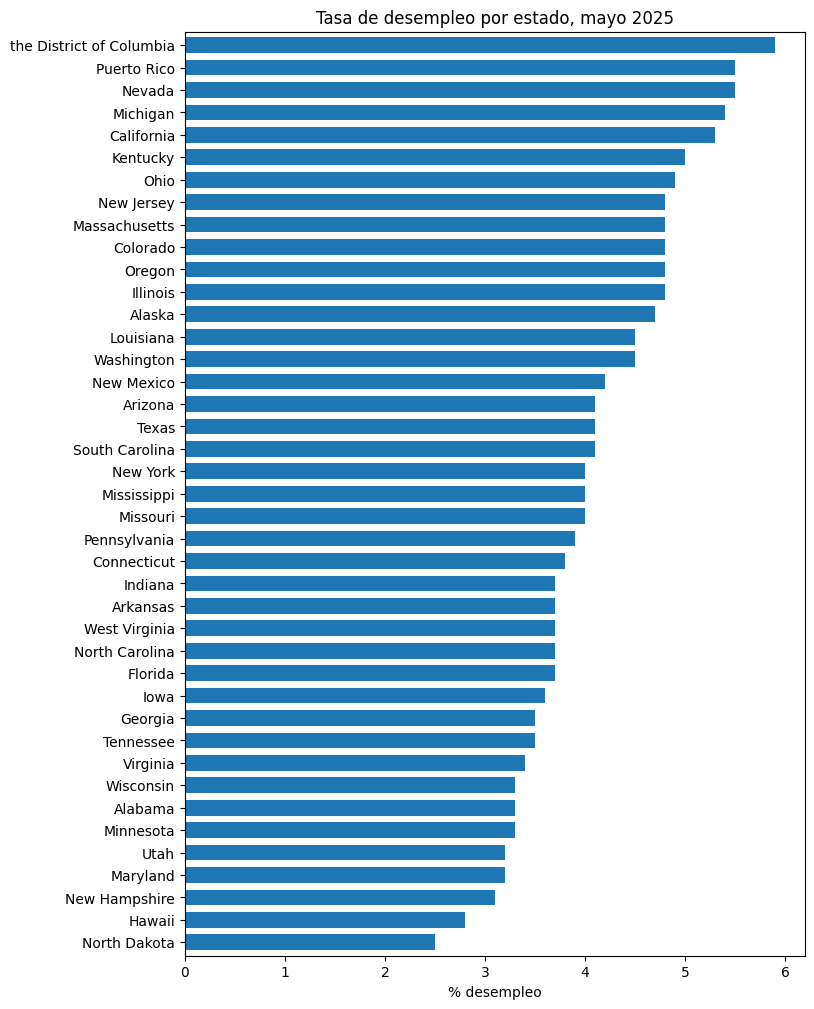

In [49]:
# Voy a hacer una grafiquita de barras
ax = datos_2025.plot(kind='barh', title='Tasa de desempleo por estado, mayo 2025', width=0.7, figsize=(8, 12))
ax.legend().remove()
ax.set_xlabel('% desempleo')
plt.show()

+ Hagamos otra búsqueda relacionada

+ La *Labor Force Participation Rate* (Tasa de Participación Laboral) es el porcentaje de la población en edad de trabajar (generalmente 15 o 16 años en adelante) que está empleada o busca trabajo activamente. Mide la oferta de mano de obra disponible y excluye a estudiantes, jubilados o personas que no buscan empleo.

+ Vamos a seguir un procedimiento similar al anterior

+ Filtramos la búsqueda con la función search

+ Filtramos aún más la búsqueda con funciones de pandas

In [50]:
# Esto es como si buscara en el browser web
busqueda_part = objeto_fred.search('participation rate state', filter=('frequency','Monthly'))
# Refino la búsqueda con operaciones de pandas
busqueda_part = busqueda_part.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')

In [51]:
busqueda_part

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
CIVPART,CIVPART,2026-03-19,2026-03-19,Labor Force Participation Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:15:18-06:00,82,The series comes from the 'Current Population ...
LNS11300060,LNS11300060,2026-03-19,2026-03-19,Labor Force Participation Rate - 25-54 Yrs.,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:15:13-06:00,64,The series comes from the 'Current Population ...
LNS11300002,LNS11300002,2026-03-19,2026-03-19,Labor Force Participation Rate - Women,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:15:13-06:00,62,To obtain estimates of women worker employment...
LNS11300001,LNS11300001,2026-03-19,2026-03-19,Labor Force Participation Rate - Men,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:15:14-06:00,56,The series comes from the 'Current Population ...
LNS11300012,LNS11300012,2026-03-19,2026-03-19,Labor Force Participation Rate - 16-19 Yrs.,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:15:15-06:00,47,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LRIN74FEUSM156S,LRIN74FEUSM156S,2026-03-19,2026-03-19,Infra-Annual Labor Statistics: Inactivity Rate...,1981-01-01,2025-09-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2025-12-15 15:10:55-06:00,0,OECD Data Filters: REF_AREA: USA MEASURE: OLF...
EMSHRNLP,EMSHRNLP,2026-03-19,2026-03-19,Monthly Share of Prime-Age U.S. Workers Who Le...,1978-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-15 13:18:36-05:00,9,Ellieroth and Michaud (EM) share of workers wh...
EMSHRNQP,EMSHRNQP,2026-03-19,2026-03-19,Monthly Share of Prime-Age U.S. Workers Who Le...,1978-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-15 13:18:35-05:00,8,Ellieroth and Michaud (EM) share of workers wh...


+ En algunos de estos renglones vienen información de las series por estado.

+ Como antes, sólo hemos hecho búsquedas, no hemos descargado nada aún.

In [52]:
# Vamos a empezar a descargar
# En esta lista guardaremos todas nuestras series
resultados_part = []

for id in busqueda_part.index:
    results = objeto_fred.get_series(id)
    results = results.to_frame(name = id)
    resultados_part.append(results)
    time.sleep(0.1) # Para modular el ritmo de las consultas porque FRED te puede bloquear

In [53]:
# Vamos a poner todas esas series en un dataframe
df_descargas_part = pd.concat(resultados_part, axis=1)

In [54]:
df_descargas_part

,CIVPART,LNS11300060,LNS11300002,LNS11300001,LNS11300012,LNS11324230,LBSSA13,LBSSA01,LBSSA22,LBSSA28,...,LRIN24FEUSM156S,LRIN74MAUSM156S,LRIN55FEUSM156S,LRINTTMAUSM156S,LRIN64FEUSM156S,LRIN74FEUSM156S,EMSHRNLP,EMSHRNQP,EMSHRNLA,EMSHRNQA
1948-01-01,58.6,64.2,32.0,86.7,53.2,43.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-02-01,58.9,64.6,32.4,87.0,53.7,43.3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-03-01,58.5,64.3,32.1,86.3,54.1,43.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-04-01,59.0,64.8,33.0,86.6,54.2,43.4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-05-01,58.3,64.3,32.0,86.1,50.9,43.2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,37.256721,86.248169,47.376194,93.590760
2025-11-01,62.5,83.8,57.4,67.7,36.3,37.9,60.6,57.6,58.2,55.6,...,NaN,NaN,NaN,NaN,NaN,NaN,37.113148,86.083618,46.310069,94.267790
2025-12-01,62.4,83.8,57.3,67.7,36.6,37.9,60.7,57.7,58.3,55.6,...,NaN,NaN,NaN,NaN,NaN,NaN,46.821350,84.258080,51.434369,94.349752
2026-01-01,62.1,84.0,57.2,67.3,35.4,37.3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,44.924191,89.497055,45.551660,95.156069


+ Como antes, cada columna representa una serie

+ Como antes, hay series que no me interesan.

+ Alguien me sopló (la documentación y la búsqueda) que las claves que me interesan son las que tienen 7 caracteres. Voy a deshacerme de las que tienen longitud mayor

In [55]:
cols_eliminar = []

for i in df_descargas_part:
    if len(i) > 7:
        cols_eliminar.append(i)

In [56]:
cols_eliminar

['LNS11300060',
 'LNS11300002',
 'LNS11300001',
 'LNS11300012',
 'LNS11324230',
 'LRAC25MAUSM156S',
 'LNS11300036',
 'LRAC25FEUSM156S',
 'LNS11327662',
 'LNS11300006',
 'LNS11300028',
 'LNS11327660',
 'LNS11300032',
 'LNS11300031',
 'LNS11300029',
 'LNS11300003',
 'LNS11300009',
 'LNS11300026',
 'LNS11327689',
 'LNS11327659',
 'LRAC64TTUSM156S',
 'LNS11300025',
 'LRAC55TTUSM156S',
 'LRAC25TTUSM156S',
 'LRIN25MAUSM156S',
 'LRAC55MAUSM156S',
 'LRAC55FEUSM156S',
 'LRAC24TTUSM156S',
 'LRAC24FEUSM156S',
 'LRAC74MAUSM156S',
 'LRAC64FEUSM156S',
 'LNS11300015',
 'LRAC64MAUSM156S',
 'LRACTTFEUSM156S',
 'LRAC74TTUSM156S',
 'LRINTTTTUSM156S',
 'LRIN25FEUSM156S',
 'LRIN64TTUSM156S',
 'LRIN64MAUSM156S',
 'LNS11300018',
 'LRAC24MAUSM156S',
 'LRIN55MAUSM156S',
 'LRIN24MAUSM156S',
 'LRACTTMAUSM156S',
 'LRACTTTTUSM156S',
 'LRAC74FEUSM156S',
 'LRINTTFEUSM156S',
 'LRIN74TTUSM156S',
 'LRIN25TTUSM156S',
 'LRIN55TTUSM156S',
 'LRIN24TTUSM156S',
 'LRIN24FEUSM156S',
 'LRIN74MAUSM156S',
 'LRIN55FEUSM156S',
 'LR

In [57]:
# Eliminamos las columnas identificadas como no deseadas
df_descargas_part = df_descargas_part.drop(columns = cols_eliminar)

In [58]:
df_descargas_part

,CIVPART,LBSSA13,LBSSA01,LBSSA22,LBSSA28,LBSSA06,LBSSA39,LBSSA26,LBSSA27,LBSSA51,...,LBSSA02,LBSSA15,LBSSA11,LBSSA16,LBSSA32,LBSSA56,LBSSA46,LBSSA29,LBSSA20,LBSSA30
1948-01-01,58.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-02-01,58.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-03-01,58.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-04-01,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-05-01,58.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,62.5,60.6,57.6,58.2,55.6,62.5,62.3,61.1,68.2,64.3,...,65.6,60.4,71.0,62.9,62.9,61.3,68.3,63.9,67.4,62.3
2025-12-01,62.4,60.7,57.7,58.3,55.6,62.6,62.3,61.0,68.2,64.3,...,65.8,60.5,71.0,62.9,63.2,61.3,68.3,64.0,67.5,62.4
2026-01-01,62.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


+ Los nombres de las columnas aunque son códigos, parecen tener cierto patrón.

+ Me huele que la columna "CIVPART" es una intrusa

In [60]:
# Por orden, trabajaré en una copia
mis_otras_series_historicas = df_descargas_part.copy()

In [61]:
mis_otras_series_historicas

,CIVPART,LBSSA13,LBSSA01,LBSSA22,LBSSA28,LBSSA06,LBSSA39,LBSSA26,LBSSA27,LBSSA51,...,LBSSA02,LBSSA15,LBSSA11,LBSSA16,LBSSA32,LBSSA56,LBSSA46,LBSSA29,LBSSA20,LBSSA30
1948-01-01,58.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-02-01,58.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-03-01,58.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-04-01,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-05-01,58.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,62.5,60.6,57.6,58.2,55.6,62.5,62.3,61.1,68.2,64.3,...,65.6,60.4,71.0,62.9,62.9,61.3,68.3,63.9,67.4,62.3
2025-12-01,62.4,60.7,57.7,58.3,55.6,62.6,62.3,61.0,68.2,64.3,...,65.8,60.5,71.0,62.9,63.2,61.3,68.3,64.0,67.5,62.4
2026-01-01,62.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
# Vamos a quitar todos los NaNs
mis_otras_series_historicas = mis_otras_series_historicas.dropna()

In [63]:
mis_otras_series_historicas

,CIVPART,LBSSA13,LBSSA01,LBSSA22,LBSSA28,LBSSA06,LBSSA39,LBSSA26,LBSSA27,LBSSA51,...,LBSSA02,LBSSA15,LBSSA11,LBSSA16,LBSSA32,LBSSA56,LBSSA46,LBSSA29,LBSSA20,LBSSA30
1976-01-01,61.3,63.8,57.1,56.9,58.8,62.5,61.7,61.6,65.5,65.9,...,69.3,69.9,64.4,63.1,71.4,65.3,64.8,60.5,65.2,62.5
1976-02-01,61.3,63.6,56.9,56.7,58.6,62.4,61.6,61.5,65.4,65.7,...,68.6,69.7,64.5,62.9,70.8,65.0,64.7,60.4,65.1,62.4
1976-03-01,61.3,63.5,56.8,56.5,58.5,62.2,61.6,61.5,65.3,65.5,...,68.1,69.6,64.6,62.8,70.5,64.8,64.6,60.3,65.0,62.3
1976-04-01,61.6,63.6,56.8,56.5,58.5,62.2,61.6,61.6,65.3,65.4,...,68.2,69.4,64.6,62.8,70.5,65.0,64.6,60.4,65.1,62.1
1976-05-01,61.5,63.6,56.8,56.5,58.5,62.2,61.5,61.7,65.5,65.4,...,68.2,69.3,64.4,62.9,70.6,65.2,64.6,60.6,65.2,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,62.2,60.6,57.9,58.0,55.9,62.4,62.6,61.6,68.1,64.9,...,65.2,60.5,71.9,63.2,62.9,61.8,68.7,63.5,66.9,62.1
2025-08-01,62.3,60.6,57.7,58.0,55.7,62.4,62.5,61.5,68.1,64.7,...,65.2,60.4,71.6,63.1,62.8,61.6,68.5,63.6,67.0,62.1
2025-09-01,62.5,60.6,57.7,58.0,55.6,62.4,62.4,61.3,68.1,64.6,...,65.3,60.4,71.3,63.0,62.7,61.5,68.4,63.7,67.1,62.2
2025-11-01,62.5,60.6,57.6,58.2,55.6,62.5,62.3,61.1,68.2,64.3,...,65.6,60.4,71.0,62.9,62.9,61.3,68.3,63.9,67.4,62.3


+ De nuevo, los nombres de las columnas son un lío

+ Tengo que ponerle nombres legibles

In [65]:
busqueda_part.head(15)

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
CIVPART,CIVPART,2026-03-19,2026-03-19,Labor Force Participation Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:15:18-06:00,82,The series comes from the 'Current Population ...
LNS11300060,LNS11300060,2026-03-19,2026-03-19,Labor Force Participation Rate - 25-54 Yrs.,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:15:13-06:00,64,The series comes from the 'Current Population ...
LNS11300002,LNS11300002,2026-03-19,2026-03-19,Labor Force Participation Rate - Women,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:15:13-06:00,62,To obtain estimates of women worker employment...
LNS11300001,LNS11300001,2026-03-19,2026-03-19,Labor Force Participation Rate - Men,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:15:14-06:00,56,The series comes from the 'Current Population ...
LNS11300012,LNS11300012,2026-03-19,2026-03-19,Labor Force Participation Rate - 16-19 Yrs.,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:15:15-06:00,47,The series comes from the 'Current Population ...
LNS11324230,LNS11324230,2026-03-19,2026-03-19,Labor Force Participation Rate - 55 Yrs. & over,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:15:20-06:00,47,The series comes from the 'Current Population ...
LBSSA13,LBSSA13,2026-03-19,2026-03-19,Labor Force Participation Rate for Georgia,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-29 11:40:41-06:00,32,A state's labor-force participation rate is th...
LBSSA01,LBSSA01,2026-03-19,2026-03-19,Labor Force Participation Rate for Alabama,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-29 11:40:43-06:00,23,A state's labor-force participation rate is th...
LBSSA22,LBSSA22,2026-03-19,2026-03-19,Labor Force Participation Rate for Louisiana,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-29 11:40:34-06:00,28,A state's labor-force participation rate is th...


+ Nótese que en el título de las series de los estados aparece la frase "Labor Force Participacion Rate for"

In [66]:
dic_id_con_letra = busqueda_part['title'].str.replace('Labor Force Participation Rate for ','').to_dict()
dic_id_con_letra

{'CIVPART': 'Labor Force Participation Rate',
 'LNS11300060': 'Labor Force Participation Rate - 25-54 Yrs.',
 'LNS11300002': 'Labor Force Participation Rate - Women',
 'LNS11300001': 'Labor Force Participation Rate - Men',
 'LNS11300012': 'Labor Force Participation Rate - 16-19 Yrs.',
 'LNS11324230': 'Labor Force Participation Rate - 55 Yrs. & over',
 'LBSSA13': 'Georgia',
 'LBSSA01': 'Alabama',
 'LBSSA22': 'Louisiana',
 'LBSSA28': 'Mississippi',
 'LRAC25MAUSM156S': 'Infra-Annual Labor Statistics: Labor Force Participation Rate Male: From 25 to 54 Years for United States',
 'LNS11300036': 'Labor Force Participation Rate - 20-24 Yrs.',
 'LRAC25FEUSM156S': 'Infra-Annual Labor Statistics: Labor Force Participation Rate Female: From 25 to 54 Years for United States',
 'LNS11327662': "Labor Force Participation Rate - Bachelor's Degree and Higher, 25 Yrs. & over",
 'LNS11300006': 'Labor Force Participation Rate - Black or African American',
 'LBSSA06': 'California',
 'LNS11300028': 'Labor Fo

In [67]:
# Me tengo que quedar solo con las claves de los estados
nombres_estados = [dic_id_con_letra[j] for j in mis_otras_series_historicas.columns]
nombres_estados

['Labor Force Participation Rate',
 'Georgia',
 'Alabama',
 'Louisiana',
 'Mississippi',
 'California',
 'Ohio',
 'Michigan',
 'Minnesota',
 'Virginia',
 'Texas',
 'Wisconsin',
 'Massachusetts',
 'West Virginia',
 'Illinois',
 'New Mexico',
 'Kentucky',
 'Maryland',
 'Utah',
 'Pennsylvania',
 'Florida',
 'Tennessee',
 'New York',
 'Colorado',
 'Washington',
 'Maine',
 'New Jersey',
 'Connecticut',
 'Indiana',
 'Oregon',
 'North Carolina',
 'Arizona',
 'Iowa',
 'Rhode Island',
 'North Dakota',
 'Nebraska',
 'Vermont',
 'Delaware',
 'New Hampshire',
 'Oklahoma',
 'South Carolina',
 'Arkansas',
 'Alaska',
 'Hawaii',
 'District Of Columbia',
 'Idaho',
 'Nevada',
 'Wyoming',
 'South Dakota',
 'Missouri',
 'Kansas',
 'Montana']

In [68]:
# Tengo que reducir el diccionario, sólo a los estados
dicc_nombres = {key: value for key, value in dic_id_con_letra.items() if value in nombres_estados}
dicc_nombres

{'CIVPART': 'Labor Force Participation Rate',
 'LBSSA13': 'Georgia',
 'LBSSA01': 'Alabama',
 'LBSSA22': 'Louisiana',
 'LBSSA28': 'Mississippi',
 'LBSSA06': 'California',
 'LBSSA39': 'Ohio',
 'LBSSA26': 'Michigan',
 'LBSSA27': 'Minnesota',
 'LBSSA51': 'Virginia',
 'LBSSA48': 'Texas',
 'LBSSA55': 'Wisconsin',
 'LBSSA25': 'Massachusetts',
 'LBSSA54': 'West Virginia',
 'LBSSA17': 'Illinois',
 'LBSSA35': 'New Mexico',
 'LBSSA21': 'Kentucky',
 'LBSSA24': 'Maryland',
 'LBSSA49': 'Utah',
 'LBSSA42': 'Pennsylvania',
 'LBSSA12': 'Florida',
 'LBSSA47': 'Tennessee',
 'LBSSA36': 'New York',
 'LBSSA08': 'Colorado',
 'LBSSA53': 'Washington',
 'LBSSA23': 'Maine',
 'LBSSA34': 'New Jersey',
 'LBSSA09': 'Connecticut',
 'LBSSA18': 'Indiana',
 'LBSSA41': 'Oregon',
 'LBSSA37': 'North Carolina',
 'LBSSA04': 'Arizona',
 'LBSSA19': 'Iowa',
 'LBSSA44': 'Rhode Island',
 'LBSSA38': 'North Dakota',
 'LBSSA31': 'Nebraska',
 'LBSSA50': 'Vermont',
 'LBSSA10': 'Delaware',
 'LBSSA33': 'New Hampshire',
 'LBSSA40': 'Okla

+ 'CIVPART': 'Labor Force Participation Rate', efectivamente es una serie intrusa

In [69]:
# Vamos a renombrar las columnas en función al diccionario que armamos
mis_otras_series_historicas = mis_otras_series_historicas.rename(columns = dicc_nombres)

In [70]:
mis_otras_series_historicas

,Labor Force Participation Rate,Georgia,Alabama,Louisiana,Mississippi,California,Ohio,Michigan,Minnesota,Virginia,...,Alaska,Hawaii,District Of Columbia,Idaho,Nevada,Wyoming,South Dakota,Missouri,Kansas,Montana
1976-01-01,61.3,63.8,57.1,56.9,58.8,62.5,61.7,61.6,65.5,65.9,...,69.3,69.9,64.4,63.1,71.4,65.3,64.8,60.5,65.2,62.5
1976-02-01,61.3,63.6,56.9,56.7,58.6,62.4,61.6,61.5,65.4,65.7,...,68.6,69.7,64.5,62.9,70.8,65.0,64.7,60.4,65.1,62.4
1976-03-01,61.3,63.5,56.8,56.5,58.5,62.2,61.6,61.5,65.3,65.5,...,68.1,69.6,64.6,62.8,70.5,64.8,64.6,60.3,65.0,62.3
1976-04-01,61.6,63.6,56.8,56.5,58.5,62.2,61.6,61.6,65.3,65.4,...,68.2,69.4,64.6,62.8,70.5,65.0,64.6,60.4,65.1,62.1
1976-05-01,61.5,63.6,56.8,56.5,58.5,62.2,61.5,61.7,65.5,65.4,...,68.2,69.3,64.4,62.9,70.6,65.2,64.6,60.6,65.2,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,62.2,60.6,57.9,58.0,55.9,62.4,62.6,61.6,68.1,64.9,...,65.2,60.5,71.9,63.2,62.9,61.8,68.7,63.5,66.9,62.1
2025-08-01,62.3,60.6,57.7,58.0,55.7,62.4,62.5,61.5,68.1,64.7,...,65.2,60.4,71.6,63.1,62.8,61.6,68.5,63.6,67.0,62.1
2025-09-01,62.5,60.6,57.7,58.0,55.6,62.4,62.4,61.3,68.1,64.6,...,65.3,60.4,71.3,63.0,62.7,61.5,68.4,63.7,67.1,62.2
2025-11-01,62.5,60.6,57.6,58.2,55.6,62.5,62.3,61.1,68.2,64.3,...,65.6,60.4,71.0,62.9,62.9,61.3,68.3,63.9,67.4,62.3


In [71]:
mis_otras_series_historicas.columns

Index(['Labor Force Participation Rate', 'Georgia', 'Alabama', 'Louisiana',
       'Mississippi', 'California', 'Ohio', 'Michigan', 'Minnesota',
       'Virginia', 'Texas', 'Wisconsin', 'Massachusetts', 'West Virginia',
       'Illinois', 'New Mexico', 'Kentucky', 'Maryland', 'Utah',
       'Pennsylvania', 'Florida', 'Tennessee', 'New York', 'Colorado',
       'Washington', 'Maine', 'New Jersey', 'Connecticut', 'Indiana', 'Oregon',
       'North Carolina', 'Arizona', 'Iowa', 'Rhode Island', 'North Dakota',
       'Nebraska', 'Vermont', 'Delaware', 'New Hampshire', 'Oklahoma',
       'South Carolina', 'Arkansas', 'Alaska', 'Hawaii',
       'District Of Columbia', 'Idaho', 'Nevada', 'Wyoming', 'South Dakota',
       'Missouri', 'Kansas', 'Montana'],
      dtype='object')

+ Voy a quitar a la columna intrusa

In [72]:
mis_otras_series_historicas = mis_otras_series_historicas.drop(columns = 'Labor Force Participation Rate')

In [73]:
mis_otras_series_historicas

,Georgia,Alabama,Louisiana,Mississippi,California,Ohio,Michigan,Minnesota,Virginia,Texas,...,Alaska,Hawaii,District Of Columbia,Idaho,Nevada,Wyoming,South Dakota,Missouri,Kansas,Montana
1976-01-01,63.8,57.1,56.9,58.8,62.5,61.7,61.6,65.5,65.9,63.7,...,69.3,69.9,64.4,63.1,71.4,65.3,64.8,60.5,65.2,62.5
1976-02-01,63.6,56.9,56.7,58.6,62.4,61.6,61.5,65.4,65.7,63.5,...,68.6,69.7,64.5,62.9,70.8,65.0,64.7,60.4,65.1,62.4
1976-03-01,63.5,56.8,56.5,58.5,62.2,61.6,61.5,65.3,65.5,63.3,...,68.1,69.6,64.6,62.8,70.5,64.8,64.6,60.3,65.0,62.3
1976-04-01,63.6,56.8,56.5,58.5,62.2,61.6,61.6,65.3,65.4,63.4,...,68.2,69.4,64.6,62.8,70.5,65.0,64.6,60.4,65.1,62.1
1976-05-01,63.6,56.8,56.5,58.5,62.2,61.5,61.7,65.5,65.4,63.6,...,68.2,69.3,64.4,62.9,70.6,65.2,64.6,60.6,65.2,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,60.6,57.9,58.0,55.9,62.4,62.6,61.6,68.1,64.9,64.7,...,65.2,60.5,71.9,63.2,62.9,61.8,68.7,63.5,66.9,62.1
2025-08-01,60.6,57.7,58.0,55.7,62.4,62.5,61.5,68.1,64.7,64.7,...,65.2,60.4,71.6,63.1,62.8,61.6,68.5,63.6,67.0,62.1
2025-09-01,60.6,57.7,58.0,55.6,62.4,62.4,61.3,68.1,64.6,64.7,...,65.3,60.4,71.3,63.0,62.7,61.5,68.4,63.7,67.1,62.2
2025-11-01,60.6,57.6,58.2,55.6,62.5,62.3,61.1,68.2,64.3,64.7,...,65.6,60.4,71.0,62.9,62.9,61.3,68.3,63.9,67.4,62.3


+ Listo!! Ya tenemos 51 series (una por cada estado) listas para trabajar

In [74]:
# Vamos a hacer una grafiquita rápida
px.line(mis_otras_series_historicas)

In [75]:
# Vamos a quedarnos sólo con los datos del 1 de mayo de 2025
datos_part_2025 = mis_otras_series_historicas.loc[mis_otras_series_historicas.index == '2025-05-01'].T.sort_values('2025-05-01')
datos_part_2025

,2025-05-01
West Virginia,54.3
Mississippi,56.2
South Carolina,57.5
New Mexico,57.8
Florida,57.9
Louisiana,57.9
Alabama,58.0
Kentucky,58.4
Arkansas,58.4
Delaware,59.0


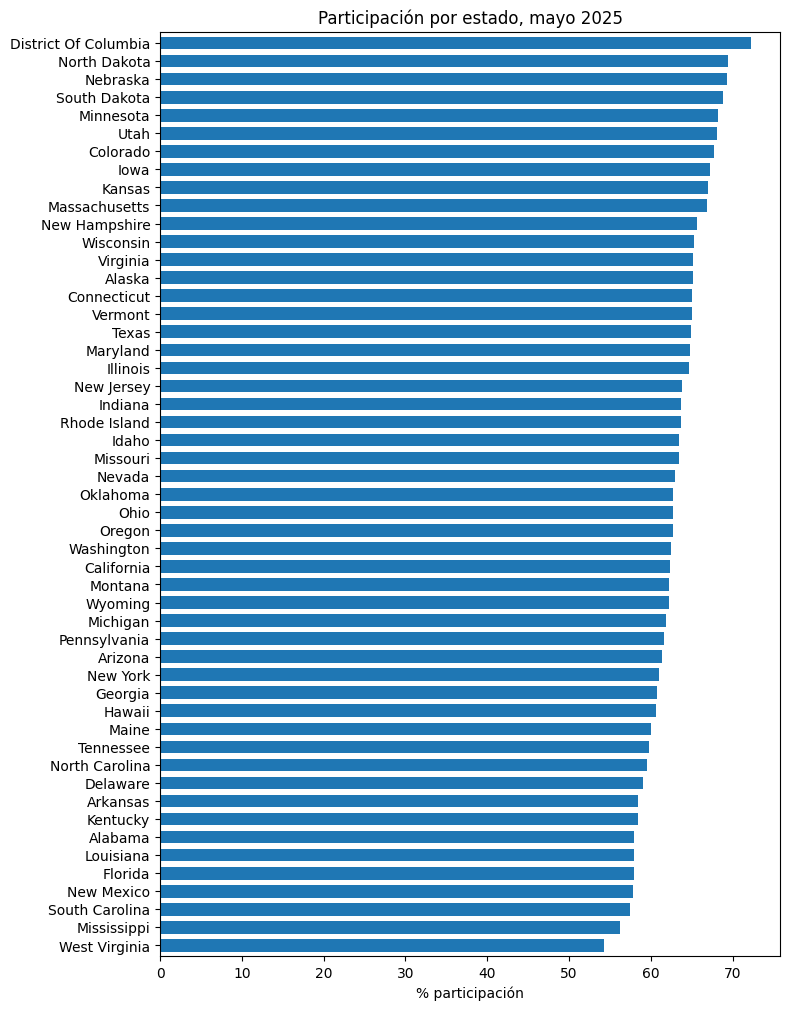

In [76]:
# Vamos a hacer mejor una visualización
ax = datos_part_2025.plot(kind='barh', title='Participación por estado, mayo 2025', width=0.7, figsize=(8, 12))
ax.legend().remove()
ax.set_xlabel('% participación')
plt.show()

¿Cómo juntamos las series del desempleo con la de participacion laboral?

In [77]:
df_desempleo = mis_series_historicas.copy()
df_part = mis_otras_series_historicas.copy()

In [79]:
df_part.head()

,Georgia,Alabama,Louisiana,Mississippi,California,Ohio,Michigan,Minnesota,Virginia,Texas,...,Alaska,Hawaii,District Of Columbia,Idaho,Nevada,Wyoming,South Dakota,Missouri,Kansas,Montana
1976-01-01,63.8,57.1,56.9,58.8,62.5,61.7,61.6,65.5,65.9,63.7,...,69.3,69.9,64.4,63.1,71.4,65.3,64.8,60.5,65.2,62.5
1976-02-01,63.6,56.9,56.7,58.6,62.4,61.6,61.5,65.4,65.7,63.5,...,68.6,69.7,64.5,62.9,70.8,65.0,64.7,60.4,65.1,62.4
1976-03-01,63.5,56.8,56.5,58.5,62.2,61.6,61.5,65.3,65.5,63.3,...,68.1,69.6,64.6,62.8,70.5,64.8,64.6,60.3,65.0,62.3
1976-04-01,63.6,56.8,56.5,58.5,62.2,61.6,61.6,65.3,65.4,63.4,...,68.2,69.4,64.6,62.8,70.5,65.0,64.6,60.4,65.1,62.1
1976-05-01,63.6,56.8,56.5,58.5,62.2,61.5,61.7,65.5,65.4,63.6,...,68.2,69.3,64.4,62.9,70.6,65.2,64.6,60.6,65.2,62.0


+ Nos gustaría tener algo del estilo

mes 1 | California | 76 | 56
mes 2 | California | 65 | 44
...

mes n | California | 75 | 68
mes 1 | New York | 34 | 87
mes 2 | New York | 65 | 98
...

+ Primero homologaré los nombres de las columnas

In [80]:
df_part.columns = (df_part.columns
                   .str.strip()
                   .str.lower()
                   .str.replace(" ", "_")
                   .str.replace("[()€$]", "", regex = True))

In [81]:
df_desempleo.columns = (df_desempleo.columns
                        .str.strip()
                        .str.lower()
                        .str.replace(" ", "_")
                        .str.replace("[()€$]", "", regex = True))

In [82]:
df_desempleo.head()

,california,texas,new_york,alabama,florida,georgia,illinois,michigan,ohio,louisiana,...,north_dakota,indiana,west_virginia,new_mexico,utah,tennessee,arkansas,connecticut,hawaii,new_hampshire
1976-01-01,9.2,5.8,10.3,6.7,9.6,8.4,6.6,9.9,8.1,6.3,...,3.5,6.6,7.4,8.6,5.8,6.0,7.3,9.7,9.6,6.5
1976-02-01,9.2,5.8,10.3,6.6,9.7,8.4,6.6,9.9,8.1,6.3,...,3.5,6.6,7.4,8.6,5.9,6.0,7.3,9.7,9.6,6.5
1976-03-01,9.1,5.9,10.2,6.6,9.6,8.3,6.6,9.9,8.1,6.3,...,3.5,6.5,7.4,8.6,5.8,6.0,7.3,9.7,9.6,6.5
1976-04-01,9.0,5.9,10.2,6.5,9.5,8.2,6.6,9.8,7.9,6.4,...,3.6,6.3,7.4,8.6,5.8,6.0,7.2,9.6,9.4,6.5
1976-05-01,8.9,6.0,10.2,6.4,9.3,8.1,6.6,9.6,7.8,6.5,...,3.6,6.0,7.4,8.6,5.7,5.9,7.1,9.4,9.3,6.5


In [83]:
df_part.head()

,georgia,alabama,louisiana,mississippi,california,ohio,michigan,minnesota,virginia,texas,...,alaska,hawaii,district_of_columbia,idaho,nevada,wyoming,south_dakota,missouri,kansas,montana
1976-01-01,63.8,57.1,56.9,58.8,62.5,61.7,61.6,65.5,65.9,63.7,...,69.3,69.9,64.4,63.1,71.4,65.3,64.8,60.5,65.2,62.5
1976-02-01,63.6,56.9,56.7,58.6,62.4,61.6,61.5,65.4,65.7,63.5,...,68.6,69.7,64.5,62.9,70.8,65.0,64.7,60.4,65.1,62.4
1976-03-01,63.5,56.8,56.5,58.5,62.2,61.6,61.5,65.3,65.5,63.3,...,68.1,69.6,64.6,62.8,70.5,64.8,64.6,60.3,65.0,62.3
1976-04-01,63.6,56.8,56.5,58.5,62.2,61.6,61.6,65.3,65.4,63.4,...,68.2,69.4,64.6,62.8,70.5,65.0,64.6,60.4,65.1,62.1
1976-05-01,63.6,56.8,56.5,58.5,62.2,61.5,61.7,65.5,65.4,63.6,...,68.2,69.3,64.4,62.9,70.6,65.2,64.6,60.6,65.2,62.0


In [84]:
# Voy a poner explícitamente una columna con la fecha
# Ahorita la fecha es indice
df_desempleo['fecha'] = df_desempleo.index
df_part['fecha'] = df_part.index

In [85]:
df_desempleo.head()

,california,texas,new_york,alabama,florida,georgia,illinois,michigan,ohio,louisiana,...,indiana,west_virginia,new_mexico,utah,tennessee,arkansas,connecticut,hawaii,new_hampshire,fecha
1976-01-01,9.2,5.8,10.3,6.7,9.6,8.4,6.6,9.9,8.1,6.3,...,6.6,7.4,8.6,5.8,6.0,7.3,9.7,9.6,6.5,1976-01-01
1976-02-01,9.2,5.8,10.3,6.6,9.7,8.4,6.6,9.9,8.1,6.3,...,6.6,7.4,8.6,5.9,6.0,7.3,9.7,9.6,6.5,1976-02-01
1976-03-01,9.1,5.9,10.2,6.6,9.6,8.3,6.6,9.9,8.1,6.3,...,6.5,7.4,8.6,5.8,6.0,7.3,9.7,9.6,6.5,1976-03-01
1976-04-01,9.0,5.9,10.2,6.5,9.5,8.2,6.6,9.8,7.9,6.4,...,6.3,7.4,8.6,5.8,6.0,7.2,9.6,9.4,6.5,1976-04-01
1976-05-01,8.9,6.0,10.2,6.4,9.3,8.1,6.6,9.6,7.8,6.5,...,6.0,7.4,8.6,5.7,5.9,7.1,9.4,9.3,6.5,1976-05-01


In [ ]:
df_part.head()

+ Esta es la parte importante

+ Voy a pasar de una tabla ancha (con muchas columnas) a una tabla larga (con muchos renglones)

+ Ocuparé la función melt

In [86]:
df_part_largo = pd.melt(df_part, id_vars=['fecha'], var_name = 'estado', value_name = 'labor_part')
df_desempleo_largo = pd.melt(df_desempleo, id_vars=['fecha'], var_name = 'estado', value_name = 'desempleo')

In [87]:
df_desempleo_largo.head()

,fecha,estado,desempleo
0,1976-01-01,california,9.2
1,1976-02-01,california,9.2
2,1976-03-01,california,9.1
3,1976-04-01,california,9.0
4,1976-05-01,california,8.9


In [ ]:
df_part_largo.head()

In [88]:
# Ahora sí las voy a juntar con un inner join
df_junto = pd.merge(df_part_largo, df_desempleo_largo, on=['fecha', 'estado'], how='inner')

In [89]:
df_junto

,fecha,estado,labor_part,desempleo
0,1976-01-01,georgia,63.8,8.4
1,1976-02-01,georgia,63.6,8.4
2,1976-03-01,georgia,63.5,8.3
3,1976-04-01,georgia,63.6,8.2
4,1976-05-01,georgia,63.6,8.1
...,...,...,...,...
23278,2025-07-01,missouri,63.5,4.1
23279,2025-08-01,missouri,63.6,4.1
23280,2025-09-01,missouri,63.7,4.1
23281,2025-11-01,missouri,63.9,4.0


+ Lo importante de las series de tiempo es la fecha, entonces haremos que la fecha de nuevo sea indice

In [90]:
df_junto = df_junto.set_index('fecha')

In [91]:
df_junto

,estado,labor_part,desempleo
fecha,,,
1976-01-01,georgia,63.8,8.4
1976-02-01,georgia,63.6,8.4
1976-03-01,georgia,63.5,8.3
1976-04-01,georgia,63.6,8.2
1976-05-01,georgia,63.6,8.1
...,...,...,...
2025-07-01,missouri,63.5,4.1
2025-08-01,missouri,63.6,4.1
2025-09-01,missouri,63.7,4.1


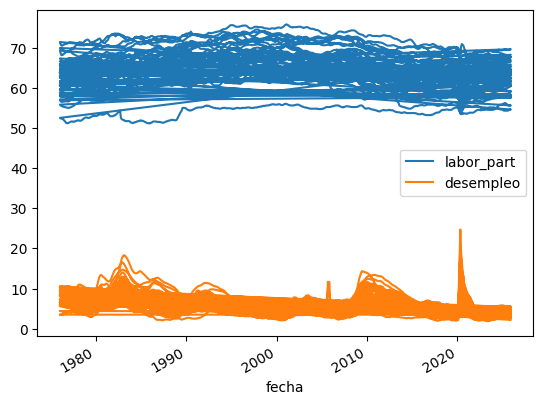

In [92]:
# Gráfica rápida
df_junto.plot()
plt.show()

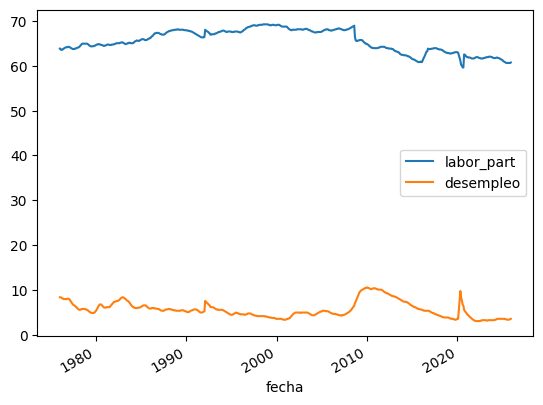

In [93]:
# Vamos a ver sólo las de Georgia
df_junto.query('estado == "georgia"').plot()
plt.show()

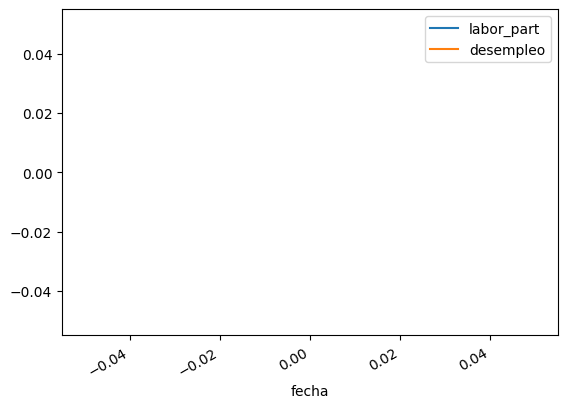

In [94]:
# Vamos a ver sólo las del distrito de columbia
df_junto.query('estado == "district_of_columbia"').plot()
plt.show()

+ ¿Qué pasó?

+ En una de las tablas aparece como 'district_of_columbia' y en la otra como 'the_district_of_columbia' y cuando hicimos el join, ambas se fueron

+ Estamos confiando demasiado en que en las bases siempre vienen bien escritos los nombres de los estados

# Otra forma un poco más dolorosa

In [ ]:
import requests

In [ ]:
base_url = 'https://api.stlouisfed.org/fred/'
obs_endpoint = 'series/observations'

series_id = 'CPIAUCSL'
start_date = '2000-01-01'
end_date = '2023-06-30'

obs_params = {
    'series_id': series_id,
    'api_key': mi_fred_key,
    'file_type': 'json',
    'observation_start': start_date,
    'observation_end': end_date
}

# Hace la solicitud a la FRED API
response = requests.get(base_url + obs_endpoint, params = obs_params)

In [ ]:
response

In [ ]:
res_data = response.json()
#res_data

In [ ]:
df_descarga = pd.DataFrame(res_data['observations'])

In [ ]:
df_descarga.head()

In [ ]:
df_descarga = df_descarga[['date','value']]

In [ ]:
df_descarga = df_descarga.set_index('date')

In [ ]:
df_descarga.head()

In [ ]:
df_descarga.info()

In [ ]:
df_descarga['value'] = df_descarga['value'].astype(float)

In [ ]:
df_descarga.head()

In [ ]:
df_descarga.plot()
plt.show()

In [ ]:
busqueda = objeto_fred.search('CPIAUCSL')

In [ ]:
busqueda

In [ ]:
cat_id = '32455'
cat_srs_endpoint = 'category/series'
cat_srs_params = {
    'api_key': mi_fred_key,
    'file_type': 'json',
    'category_id': cat_id,
}

response = requests.get(base_url + cat_srs_endpoint, params=cat_srs_params)

In [ ]:
response

In [ ]:
res_data = response.json()
#res_data

In [ ]:
df_descarga = pd.DataFrame(res_data['seriess'])

In [ ]:
df_descarga